In [72]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')

In [73]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util

In [74]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [75]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 1_000_000
BATCH_SIZE = 64
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

hidden1_size=64
hidden2_size=32

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-autoencoder-cnn-correct-{hidden1_size}-{hidden2_size}-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'model', f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'train', f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'test', f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "train", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "test", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'roc', f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'cm', f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 256

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/autoencoder/all_features/model/dol1l2-autoencoder-cnn-correct-64-32-0.2-checkpoint-1000000-100-64-0.005-0.001.pt


In [76]:
# Initialize the model
INPUT_SIZE = 3968

model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, hidden1_size=hidden1_size, hidden2_size=hidden2_size, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=3968, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [77]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [81]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/autoencoder/all_features/model/dol1l2-autoencoder-cnn-correct-64-32-0.2-checkpoint-1000000-100-64-0.005-0.001.pt exists. Resuming training from epoch 21.


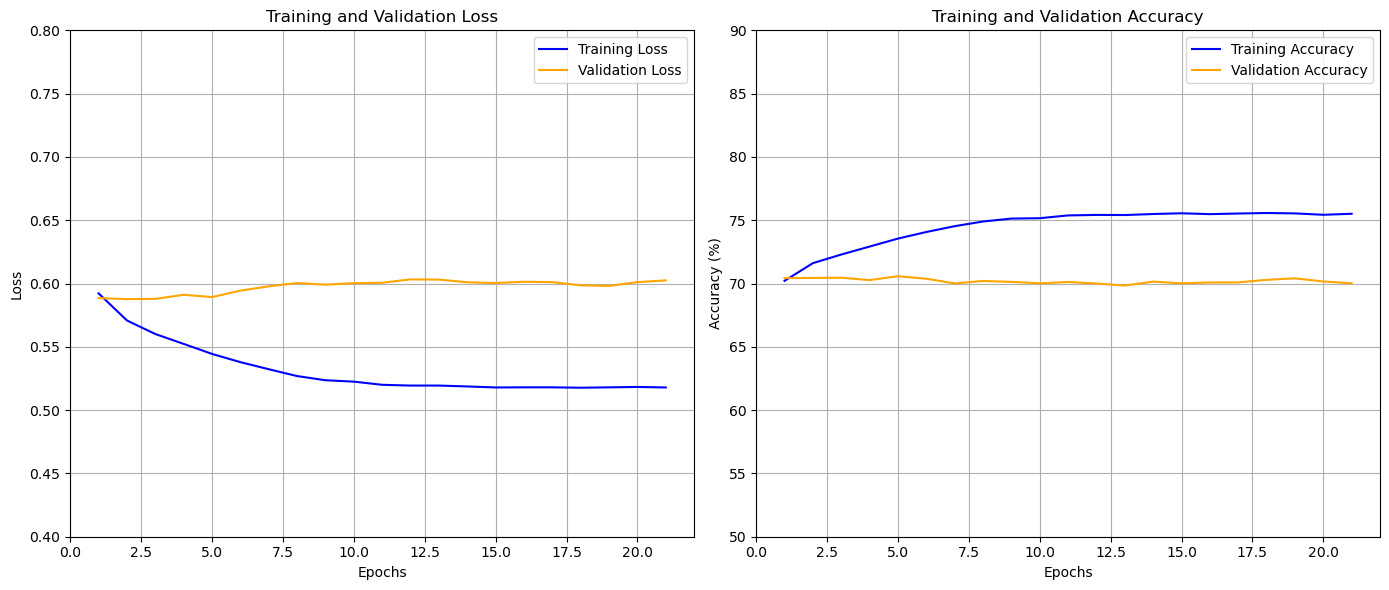

In [82]:
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [80]:
print(train_losses)
print(val_losses)
print(train_accuracies)
print(val_accuracies)

[0.5922, 0.5708, 0.5601, 0.5523, 0.5444, 0.5379, 0.5323, 0.5269, 0.5236, 0.5225, 0.52, 0.5194, 0.5194, 0.5187, 0.5179, 0.518, 0.518, 0.5177, 0.518]
[0.5885, 0.5877, 0.5879, 0.5911, 0.5893, 0.5944, 0.5978, 0.6004, 0.5991, 0.6003, 0.6006, 0.6033, 0.6031, 0.601, 0.6004, 0.6014, 0.6011, 0.5986, 0.5981]
[70.21, 71.61, 72.29, 72.92, 73.55, 74.07, 74.53, 74.9, 75.13, 75.16, 75.38, 75.42, 75.41, 75.49, 75.55, 75.48, 75.53, 75.57, 75.54]
[70.43, 70.44, 70.46, 70.27, 70.58, 70.38, 70.01, 70.2, 70.13, 70.02, 70.12, 70.0, 69.84, 70.15, 70.02, 70.08, 70.09, 70.29, 70.41]
